# Google (GOOGL) Stock Analysis

This Project analyzes Alphabet Inc. (GOOGL) using Python and historical market data from Yahoo Finance. 

## Project Goals
- Analyze historical stock prices and returns 
- Caclulate moving averages and RSI
- Build and backtest trading strategies
- Compare strategy performance against buy-and-hold
- Measure risk using volatility, Sharpe ratio, and maximum drawdown
- Estimate CAPM alpha and beta
- Explore machine learning models for predicting stock direction

In [36]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [37]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

## 1. Historical Stock Data
We begin by downloading historical price data for Alphabet Inc. (GOOGL) using Yahoo Finance.

In [38]:
ticker = 'GOOGL'

data = yf.download(
    ticker,
    start = '2015-01-01',
    end = '2026-09-12',
    progress = False
)

data.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2015-01-02,26.227922,26.537477,26.145208,26.378983,26480000
2015-01-05,25.728178,26.150658,25.643485,26.109054,41182000
2015-01-06,25.093224,25.814855,25.039237,25.779690,54456000
2015-01-07,25.019424,25.333436,24.945133,25.306692,46918000
2015-01-08,25.106594,25.135815,24.517696,24.839139,73054000


In [39]:
data.shape

(2940, 5)

In [40]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2026-09-04,338.459991,343.529999,337.089996,342.470001,23189300
2026-09-08,338.359985,339.679993,333.220001,335.420013,22915800
2026-09-09,330.649994,331.850006,327.899994,331.649994,33151600
2026-09-10,332.600006,333.230011,327.739990,328.230011,23557600
2026-09-11,338.500000,342.980011,335.029999,335.029999,24708300


## 2. Data Cleaning and Basic Checks
Before analyzing the stock, we check the dataset for missing values and duplicate observations.

In [41]:
print('Missing values:')
print(data.isnull().sum())

print('\nDuplicate rows:')
print(data.duplicated().sum())

Missing values:
Price   Ticker
Close   GOOGL     0
High    GOOGL     0
Low     GOOGL     0
Open    GOOGL     0
Volume  GOOGL     0
dtype: int64

Duplicate rows:
0


## 3. Exploratory Data Analysis

Now that the dataset is clean, we can examine Google's historical stock performance, price movement, returns, and trading patterns.

In [42]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
count,2940.000000,2940.000000,2940.000000,2940.000000,2.940000e+03
mean,108.117524,109.274912,106.863650,108.044565,3.503214e+07
std,80.818783,81.769039,79.725481,80.721818,1.670500e+07
min,24.618738,24.778220,24.314136,24.726710,9.312000e+06
25%,51.014685,51.694838,50.270395,51.033012,2.485050e+07
50%,82.308769,84.845137,81.467777,83.394686,3.090100e+07
75%,139.858150,141.010446,138.719359,139.829429,3.990350e+07
max,402.121185,408.103767,395.868935,399.424550,2.571620e+08


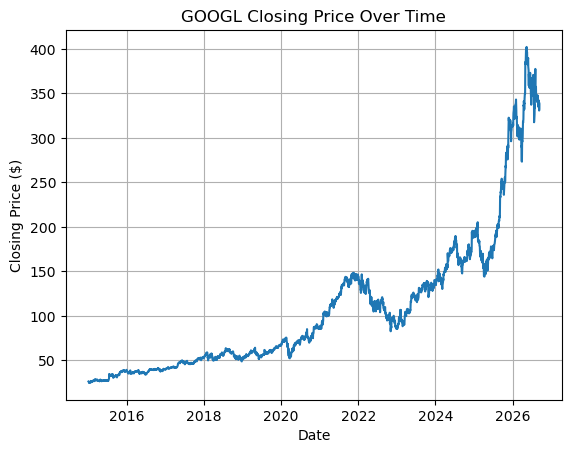

In [43]:
import matplotlib.pyplot as plt

plt.plot(data.index, data['Close']['GOOGL'])

plt.title('GOOGL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.grid(True)

plt.show()

### Closing Price Trend

GOOGL shows strong long-term growth, with periods of noticeable volatility and pullbacks.

## 4. Daily Returns

Daily returns measure the percentage change in GOOGl's closing price from one trading day to the next.

In [44]:
data['Daily Return'] = data['Close']['GOOGL'].pct_change()

data['Daily Return'].describe()

count    2939.000000
mean        0.001038
std         0.018318
min        -0.116341
25%        -0.007884
50%         0.001202
75%         0.010029
max         0.162584
Name: Daily Return, dtype: float64

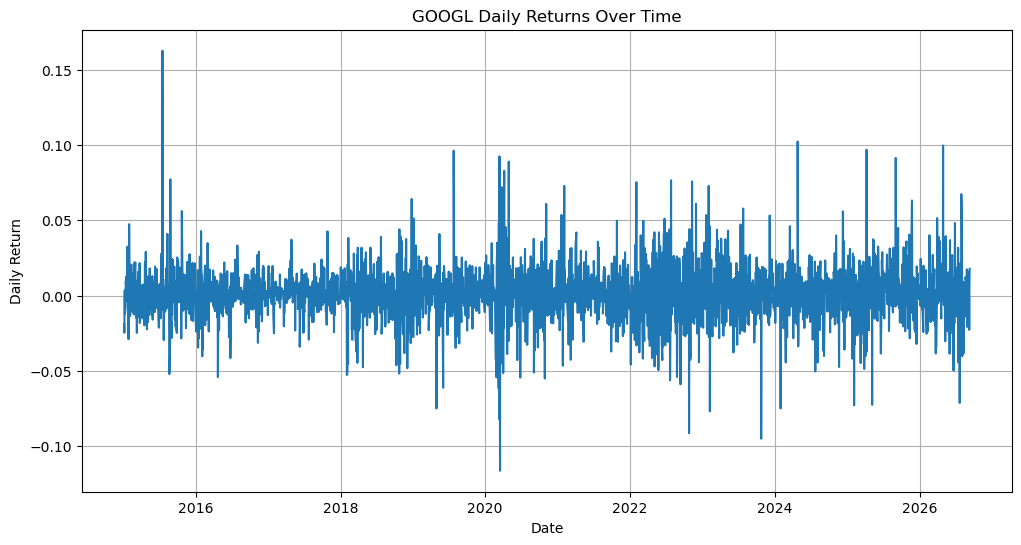

In [45]:
plt.figure(figsize=(12,6))

plt.plot(data.index, data['Daily Return'])

plt.title('GOOGL Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')

plt.grid(True)
plt.show()

### Daily Return Trend

Most daily returns stay close to zero, but several periods show larger price swings and increased volatility.

## 5. Moving Averages

Moving averages help smooth short-term price changes and make longer-term trends easier to see.

In [46]:
data['MA10'] = data['Close']['GOOGL'].rolling(window=10).mean()
data['MA50'] = data['Close']['GOOGL'].rolling(window=50).mean()

data[['MA10', 'MA50']].tail()

Price,MA10,MA50
Ticker,,
Date,,
2026-09-04,341.471265,348.349840
2026-09-08,340.523621,348.373574
2026-09-09,338.914908,347.918118
2026-09-10,337.996878,347.427309
2026-09-11,337.803760,346.977750


<function matplotlib.pyplot.show(close=None, block=None)>

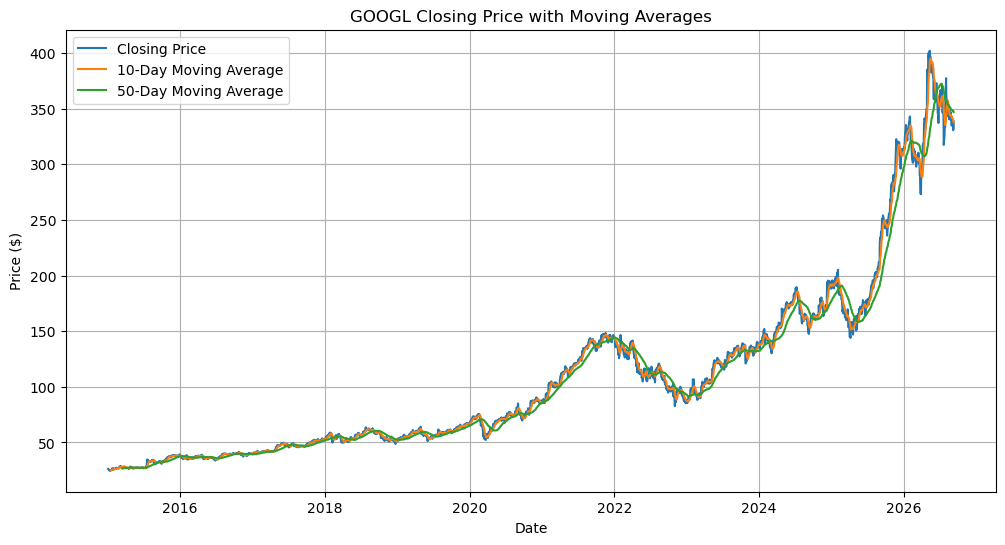

In [47]:
plt.figure(figsize=(12, 6))

plt.plot(data.index, data['Close']['GOOGL'], label='Closing Price')
plt.plot(data.index, data['MA10'], label='10-Day Moving Average')
plt.plot(data.index, data['MA50'], label='50-Day Moving Average')

plt.title('GOOGL Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')

plt.legend()
plt.grid(True)

plt.show

### Moving Average Trend

The 10-day moving average follows short-term price changes more closely, while the 50-day moving average shows the broader trend.

## 6. Moving Average Crossover Strategy

This strategy uses the relationship between the 10-day and 50-day moving averages to identify possible buy and sell signals.

In [48]:
data['Signal'] = 0
data.loc[data['MA10'] > data['MA50'], 'Signal'] = 1
data.loc[data['MA10'] < data['MA50'], 'Signal'] = -1

data[['MA10', 'MA50', 'Signal']].tail()

Price,MA10,MA50,Signal
Ticker,,,
Date,,,
2026-09-04,341.471265,348.349840,-1
2026-09-08,340.523621,348.373574,-1
2026-09-09,338.914908,347.918118,-1
2026-09-10,337.996878,347.427309,-1
2026-09-11,337.803760,346.977750,-1


In [49]:
data['Crossover'] = data['Signal'].diff()

buy_signals = data[data['Crossover'] == 2]
sell_signals = data[data['Crossover'] == -2]

print('Buy signals:', len(buy_signals))
print('Sell signals:', len(sell_signals))

Buy signals: 39
Sell signals: 40


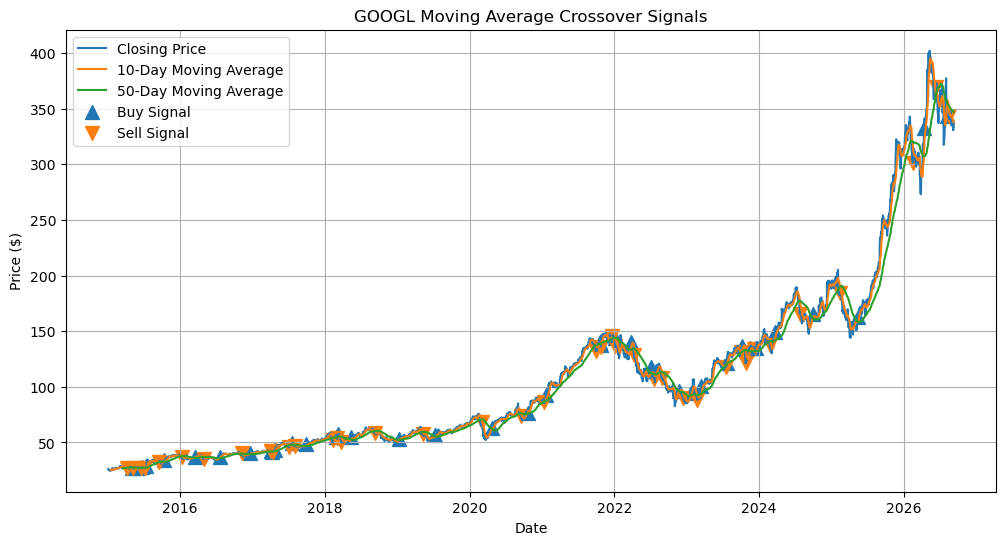

In [50]:
plt.figure(figsize=(12, 6))

plt.plot(data.index, data['Close']['GOOGL'], label='Closing Price')
plt.plot(data.index, data['MA10'], label='10-Day Moving Average')
plt.plot(data.index, data['MA50'], label='50-Day Moving Average')

plt.scatter(
    buy_signals.index,
    buy_signals['Close']['GOOGL'],
    marker='^',
    s=100,
    label='Buy Signal' 
)

plt.scatter(
    sell_signals.index,
    sell_signals['Close']['GOOGL'],
    marker='v',
    s=100,
    label='Sell Signal'
)

plt.title('GOOGL Moving Average Crossover Signals')
plt.xlabel('Date')
plt.ylabel('Price ($)')

plt.legend()
plt.grid(True)

plt.show()

### Crossover Signal Results

The strategy generated buy and sell signals when the 10-day moving average crossed above or below the 50-day moving average.

## 7. Portfolio Backtest

This backtest measures how a $100,000 portfolio would have performed using the moving average crossover strategy.

In [52]:
initial_capital = 100000

data['Position'] = (data['Signal'] == 1).astype(int)
initial_capital
data['Strategy Return'] = (
    data['Position'].shift(1).fillna(0)
    * data['Daily Return'].fillna(0)
) 

data['Portfolio Value'] = (
    initial_capital
    * (1+ data['Strategy Return']).cumprod()
)

data[['Position', 'Strategy Return', 'Portfolio Value']].tail()

Price,Position,Strategy Return,Portfolio Value
Ticker,,,
Date,,,
2026-09-04,0,-0.0,562155.869953
2026-09-08,0,-0.0,562155.869953
2026-09-09,0,-0.0,562155.869953
2026-09-10,0,0.0,562155.869953
2026-09-11,0,0.0,562155.869953


In [54]:
final_value = data['Portfolio Value'].iloc[-1]

total_return = (
    (final_value - initial_capital) / initial_capital
) * 100

print(f'Initial Portfolio Value: ${initial_capital:,.2f}')
print(f'Final Portfolio Value: ${final_value:,.2f}')
print(f'Total Return: {total_return:.2f}%')

Initial Portfolio Value: $100,000.00
Final Portfolio Value: $562,155.87
Total Return: 462.16%


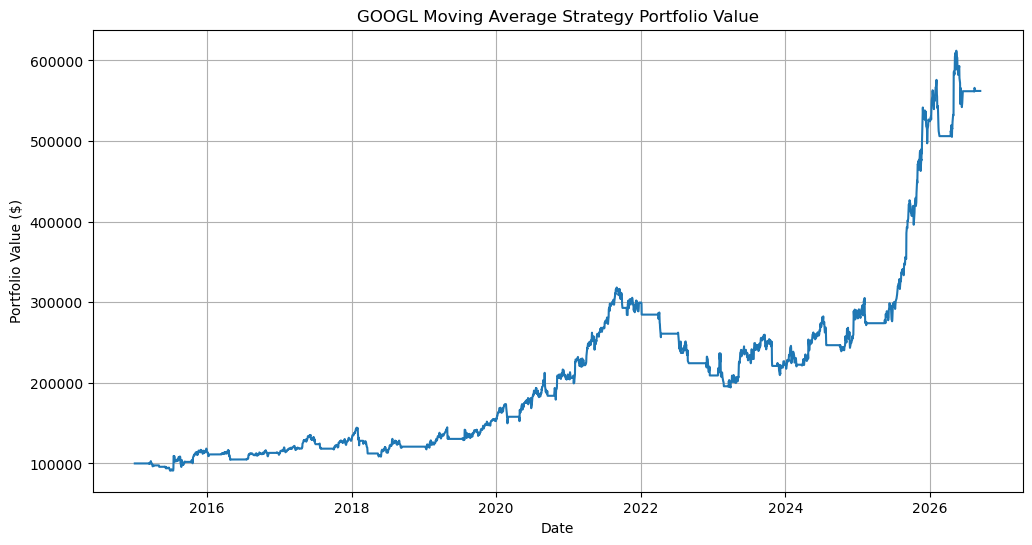

In [55]:
plt.figure(figsize=(12, 6))

plt.plot(data.index, data['Portfolio Value'])

plt.title('GOOGL Moving Average Strategy Portfolio Value')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')

plt.grid(True)
plt.show()

### Portfolio Backtest Results

The strategy grew the initial $100,000 portfolio to about $562,156, producing a total return of 462.16%. The portfolio expereicned several declines along the way, showing that the strategy still carries risk.

## 8. Feature Engineering 

This section creates variables that will be used to predict whether GOOGl's closing price will rise the next trading day.

In [56]:
data['MA Ratio'] = data['MA10'] / data['MA50']

data['Volatility'] = (
    data['Daily Return']
    .rolling(window=10)
    .std()
)

data['Volume Change'] = (
    data['Volume']['GOOGL']
    .pct_change()
)

data['Volume Change'] = (
    data['Volume']['GOOGL']
    .pct_change()
)

data['Next Close'] = (
    data['Close']['GOOGL']
    .shift(-1)
)

data['Target'] = (
    data['Next Close'] > data['Close']['GOOGL']
).astype(int)

data[['Daily Return', 'MA Ratio', 'Volatility', 'Volume Change', 'Target']].tail()

Price,Daily Return,MA Ratio,Volatility,Volume Change,Target
Ticker,,,,,
Date,,,,,
2026-09-04,-0.011103,0.980254,0.013364,0.118802,0
2026-09-08,-0.000295,0.977467,0.012809,-0.011794,0
2026-09-09,-0.022786,0.974123,0.014306,0.446670,1
2026-09-10,0.005898,0.972856,0.014217,-0.289398,1
2026-09-11,0.017739,0.973560,0.015582,0.048846,0


## 9. Preparing the Machine learning Data

The features are organized into a dataset for training and testing the prediction models.

In [57]:
ml_data = pd.DataFrame({
   'Daily Return': data['Daily Return'],
   'MA Ratio': data['MA Ratio'],
   'Volatility': data['Volatility'],
   'Volume Change': data['Volume Change'],
   'Target': data['Target'],
   'Next Close': data['Next Close'] 
}).dropna()

X = ml_data[
    ['Daily Return', 'MA Ratio', 'Volatility', 'Volume Change']
]

y = ml_data['Target']

print('Features:', X.shape)
print('Target:', y.shape)

Features: (2890, 4)
Target: (2890,)


## 10. Train-Test Split 

The data is divided chronologically so earlier observations are used for training while later observations are used for testing.

In [59]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print('Training features:', X_train.shape)
print('Testing features:', X_test.shape)

print('Training target:', y_train.shape)
print('Testing target:', y_test.shape)

Training features: (2312, 4)
Testing features: (578, 4)
Training target: (2312,)
Testing target: (578,)


## 11. Machine Learning Models

Several classification models are tested to predict whether GOOGL's closing price will rise the next trading day. 

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
   n_estimators=100,
   random_state=42 
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f'Random Forest Accuracy: {rf_accuracy:.2%}')

Random Forest Accuracy: 46.19%


In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

log_predictions = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, log_predictions)

print(f'Logistic Regression Accuracy: {log_accuracy:.2%}')

Logistic Regression Accuracy: 52.60%


In [63]:
from sklearn.svm import SVC

svc_model = SVC()

svc_model.fit(X_train_scaled, y_train)

svc_predictions = svc_model.predict(X_test_scaled)

svc_accuracy = accuracy_score(y_test, svc_predictions)

print(f'SVC Accuracy: {svc_accuracy}')

SVC Accuracy: 0.5121107266435986


## 12. Model Comparison

The three models are compared using their prediction accuracy on the testing data.

In [64]:
model_results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Logistic Regression',
        'SVC',
    ],
    'Accuracy': [
        rf_accuracy,
        log_accuracy,
        svc_accuracy
    ]
})

model_results

,Model,Accuracy
0,Random Forest,0.461938
1,Logistic Regression,0.525952
2,SVC,0.512111


In [65]:
baseline_accuracy = y_test.value_counts(normalize=True).max()

print(f'Baseline Accuracy:{baseline_accuracy:.2%}')

Baseline Accuracy:52.77%


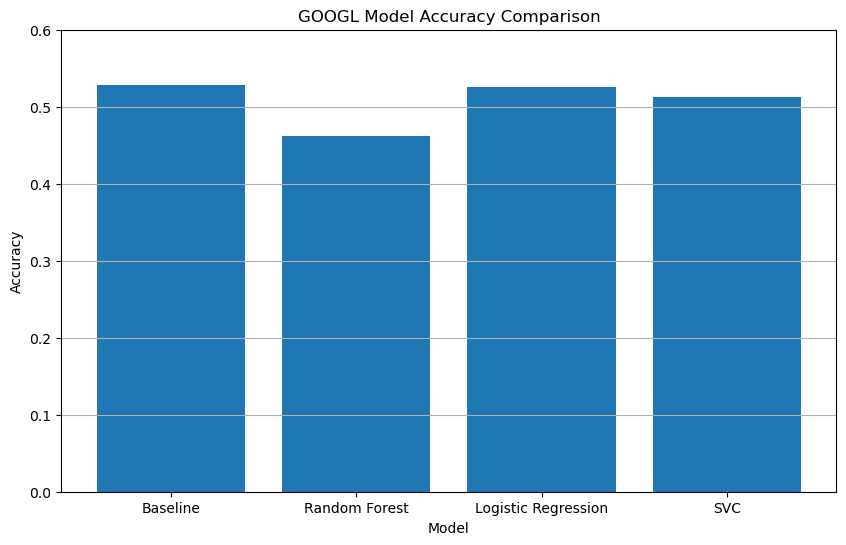

In [66]:
comparison = pd.DataFrame({
   'Model': [
       'Baseline',
       'Random Forest',
       'Logistic Regression',
       'SVC'
   ],
   'Accuracy': [
       baseline_accuracy,
       rf_accuracy,
       log_accuracy,
       svc_accuracy
   ] 
})

plt.figure(figsize=(10, 6))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.title('GOOGL Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.ylim(0, 0.6)
plt.grid(axis='y')

plt.show()

## 13. Conclusion

This project analyzed GOOGL's historical stock performance using price trends, daily returns, moving averages, a crossover strategy, and machine learning. The moving average strategy grew a $100,000 portfolio to about $562,156, producing a 462.16% return in this simplified backtest. For next-day price predicition, Logistic Regression achieved 52.60% accuracy, SVC achieved 51.21%, and Random Forest achieved 46.19%. The baseline accuracy was 52.77%, meaning none of the machine learning models outperformed the simple baseline. Overall, the results show that historical price patterns can be useful for analyzing trends, but predicting short-term stock movements remains difficult.